In [1]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [3]:
animals = ['BS_40','BS_41','BS_42','BS_49','BS_50','BS_51','BS_56','BS_59','BS_67','BS_70','BS_72','BS_87','BS_108','DS_15','DS_19']

In [12]:
df = pd.read_csv((os.path.join('..','..','Source Data Files','Figure 2l.csv')))

In [13]:
df

,Unnamed: 0,animal,session,learning phase,average lick rate,average go lick rate,post-stimulus time limit
0,0,BS_108,BS_108_1_AC.pickle,pre expert,1.362903,1.898876,0.25
1,1,BS_108,BS_108_2_AC.pickle,pre expert,0.965517,1.317647,0.25
2,2,BS_108,BS_108_3_AC.pickle,switch,0.864368,1.659292,0.25
3,3,BS_108,BS_108_4_AC.pickle,post early,1.161290,1.565217,0.25
4,4,BS_108,BS_108_6_AC.pickle,post early,1.294253,1.555249,0.25
...,...,...,...,...,...,...,...
193,193,AO_273,AO_273_5_opto_control_AC.pickle,NaN,0.429545,0.583851,0.25
194,194,AO_273,AO_273_6_opto_control_AC.pickle,NaN,0.293634,0.356608,0.25
195,195,AO_273,AO_273_7_opto_control_AC.pickle,NaN,0.155172,0.364865,0.25
196,196,AO_273,AO_273_8_opto_control_AC.pickle,NaN,0.272401,0.436782,0.25


In [14]:
lick_rate_preearly = []
lick_rate_prelate = []
lick_rate_preexpert = []
lick_rate_postearly = []
lick_rate_postlate = []
lick_rate_postexpert = []

post_stim = df['post-stimulus time limit'][0]

for row in df.iloc:
    if row['learning phase'] == 'pre early':
        lick_rate_preearly.append(row['average go lick rate']/post_stim)
    if row['learning phase'] == 'pre late':
        lick_rate_prelate.append(row['average go lick rate']/post_stim)
    if row['learning phase'] == 'pre expert':
        lick_rate_preexpert.append(row['average go lick rate']/post_stim)
        
    if row['learning phase'] == 'post early':
        lick_rate_postearly.append(row['average go lick rate']/post_stim)
    if row['learning phase'] == 'post late':
        lick_rate_postlate.append(row['average go lick rate']/post_stim)
    if row['learning phase'] == 'post expert':
        lick_rate_postexpert.append(row['average go lick rate']/post_stim)

lick_rate_preearly = np.array(lick_rate_preearly)
lick_rate_prelate = np.array(lick_rate_prelate)
lick_rate_preexpert = np.array(lick_rate_preexpert)
lick_rate_postearly = np.array(lick_rate_postearly)
lick_rate_postlate = np.array(lick_rate_postlate)
lick_rate_postexpert = np.array(lick_rate_postexpert)

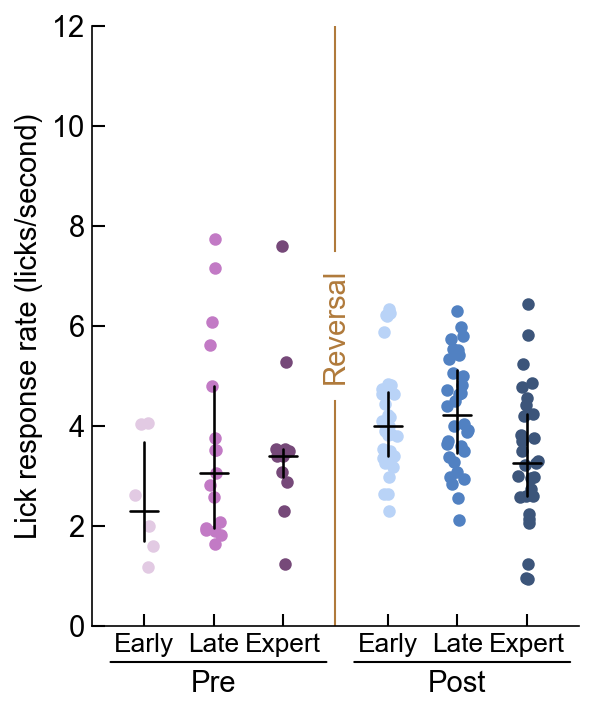

In [15]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

fig,ax = make_axis_size(3.25, 4, left=.3, bottom=.3, right=0, top=0)
switch_offset = 0.25

################################################################################################################

size = 20
summary_size=150
summary_width=1.25#0.75

mn = 3.5
spread = 2.5
    
###
    
FRmod_baseline_median = 3.5
data = [lick_rate_preearly,lick_rate_prelate,lick_rate_preexpert,lick_rate_postearly,lick_rate_postlate,lick_rate_postexpert]
labels = ['Early','Late','Expert','Early','Late','Expert']
numCon = len(data)

###
X = [np.ones(len(l))*idx + polarity*switch_offset for idx,(l,polarity) in enumerate(zip(data,[-1,-1,-1,1,1,1]))]
_,Y = ilep.violin(np.concatenate(X),np.concatenate(data),width=0.75,minjitter=0.075)
X,_ = ilep.violin(np.concatenate(X),np.log10(np.concatenate(data)),width=0.75,minjitter=0.075)
colors = NCR_CR_cmap( (Y-(mn-spread/2))/ (spread) )

#Plot summary
for idx,(column,polarity) in enumerate(zip(data,[-1,-1,-1,1,1,1])):
    column = ilep.rmnan(column)
    percentCR = np.nanmean(np.greater(column,FRmod_baseline_median))*100
    
    eye_color= 'grey'
    border_color = 'k'
    
    Q1, median, Q3 = (np.percentile(column, q) for q in [25, 50, 75])
    
    ax.plot([idx+polarity*switch_offset, idx+polarity*switch_offset], [Q1, Q3], c=border_color, lw=summary_width, zorder=9, solid_capstyle='round')
    ax.plot([idx+polarity*switch_offset-0.2, idx+polarity*switch_offset+0.2], [median,median], c=border_color, lw=summary_width, zorder=9, solid_capstyle='round')

    X,Y = ilep.violin(column,width=0.4)
    ax.scatter(X+idx+polarity*switch_offset,Y,s=25,c=PHASE_COLORS[idx],zorder=8)


################################################################################################################
labels = ['Early','Late','Expert','Early','Late','Expert']

ax.set_ylim([0,12])
ylab = ax.set_ylabel('Lick response rate (licks/second)')

ax.set_xlim([-0.75-switch_offset,5.75+switch_offset])
ax.set_xticks([0-switch_offset,1-switch_offset,2-switch_offset,3+switch_offset,4+switch_offset,5+switch_offset])
ax.set_xticklabels(labels)\

xtick_pos_pre = ax.get_xticks()[1]
xtick_pos_post = ax.get_xticks()[4]
Yval = ilep.getPrePostLabelYval(ax.get_ylim(),Yfrac=-2*stdyfrac,log=False)
t1 = ax.text(xtick_pos_pre, Yval, 'Pre', ha='center', va='bottom', fontsize=stdfont,color='k')
t2 = ax.text(xtick_pos_post, Yval, 'Post', ha='center', va='bottom',  fontsize=stdfont,color='k')
ax.annotate('', xy=(0.03, -stdyfrac), xycoords='axes fraction', xytext=(0.49, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))
ax.annotate('', xy=(0.53, -stdyfrac), xycoords='axes fraction', xytext=(0.99, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))

ax.tick_params(direction='in', length=6, width=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass

Y = np.mean(ax.get_ylim())
Y = np.mean((ax.get_ylim()))
t = ax.text(2.5,Y,'Reversal',rotation=90,fontsize=stdfont,color=SWITCH_COLOR,horizontalalignment='center',verticalalignment='center')
ax.plot([2.5]*2,[ax.get_ylim()[0],Y-1.5],lw=1,color=SWITCH_COLOR)
ax.plot([2.5]*2,[ax.get_ylim()[1],Y+1.5],lw=1,color=SWITCH_COLOR)

ax.fill_between(ax.get_xlim(),[ax.get_ylim()[0]]*2,[ax.get_ylim()[1]]*2,color='white',alpha=0.4,zorder=-5,clip_on=False)

artists = [ylab,t1,t2]

# fig.savefig(os.path.join('..','..','Figures','Figure 2l.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [10]:
data_dec = SimpleNamespace()
data_dec.preearly = np.abs(lick_rate_preearly)
data_dec.prelate = np.abs(lick_rate_prelate)
data_dec.preexpert = np.abs(lick_rate_preexpert)
data_dec.postearly = np.abs(lick_rate_postearly)
data_dec.postlate = np.abs(lick_rate_postlate)
data_dec.postexpert = np.abs(lick_rate_postexpert)
ilep.mannwhitneycompareall(data_dec)
pass

pre-early   n = 6
pre-late    n = 17
pre-expert  n = 11
post-early  n = 33
post-late   n = 32
post-expert n = 29
pre-early  to pre-late   : 0.47888495943415854
pre-late   to pre-expert : 0.7419420496381586
pre-early  to pre-expert : 0.47888495943415854
post-early to post-late  : 0.7419420496381586
post-late  to post-expert: 0.047535561031422896
post-early to post-expert: 0.047535561031422896
